# Employee attrition analysis


# objective
Objective of this project is th analyse various possible factors affecting attrition and how to inluence the factors to attrition 



# Key Questions

- Does age influence attrition?
- Which departments have higher attrition?
- Does salary influence attrition?
- Does overtime relate to attrition?
- Does burnout relate to attrition?
- Does employee engagement relate to attrition?
- Is perceived AI job risk associated with attrition?
- Does manager support influence attrition?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the CSV dataset

df= pd.read_csv("employee_attrition_hr_2026.csv")




In [4]:
df

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,...,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
0,1001,37,Male,Divorced,Masters,Engineering,Engineering Manager,3,7365,0,...,17,9.4,1.0,9.7,7.7,3,8.3,True,4.8,No
1,1002,24,Female,Married,Bachelors,Finance,Finance Manager,2,4746,2,...,21,4.2,1.9,5.4,7.8,3,8.0,True,2.9,Yes
2,1003,24,Female,Single,Bachelors,Marketing,Marketing Specialist,1,2740,2,...,22,7.5,5.3,6.5,7.0,4,9.5,True,7.2,No
3,1004,44,Male,Single,Bachelors,Sales,Sales Manager,4,7334,1,...,21,8.7,4.3,7.3,3.5,4,7.9,False,5.2,No
4,1005,37,Female,Divorced,Bachelors,Sales,Sales Development Rep,3,9096,0,...,20,7.5,2.3,7.0,7.2,4,8.5,False,6.4,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5996,40,Male,Married,Masters,Engineering,Engineering Manager,4,13662,1,...,14,5.4,6.0,6.5,4.4,4,7.5,True,4.6,Yes
4996,5997,45,Male,Single,Bachelors,Sales,Account Executive,3,7353,3,...,21,4.5,5.6,5.4,5.8,4,9.0,True,4.3,No
4997,5998,33,Male,Married,Masters,Research & Development,Product Researcher,1,3746,2,...,15,6.5,2.0,5.0,8.5,3,7.2,False,4.8,No
4998,5999,36,Female,Married,Masters,Finance,Finance Manager,4,9430,1,...,31,5.7,2.4,5.9,8.2,3,6.8,False,4.5,No


In [5]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 5000
Number of columns: 29


In [6]:
df.head()

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,...,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
0,1001,37,Male,Divorced,Masters,Engineering,Engineering Manager,3,7365,0,...,17,9.4,1.0,9.7,7.7,3,8.3,True,4.8,No
1,1002,24,Female,Married,Bachelors,Finance,Finance Manager,2,4746,2,...,21,4.2,1.9,5.4,7.8,3,8.0,True,2.9,Yes
2,1003,24,Female,Single,Bachelors,Marketing,Marketing Specialist,1,2740,2,...,22,7.5,5.3,6.5,7.0,4,9.5,True,7.2,No
3,1004,44,Male,Single,Bachelors,Sales,Sales Manager,4,7334,1,...,21,8.7,4.3,7.3,3.5,4,7.9,False,5.2,No
4,1005,37,Female,Divorced,Bachelors,Sales,Sales Development Rep,3,9096,0,...,20,7.5,2.3,7.0,7.2,4,8.5,False,6.4,No


In [7]:
df.tail()

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,...,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
4995,5996,40,Male,Married,Masters,Engineering,Engineering Manager,4,13662,1,...,14,5.4,6.0,6.5,4.4,4,7.5,True,4.6,Yes
4996,5997,45,Male,Single,Bachelors,Sales,Account Executive,3,7353,3,...,21,4.5,5.6,5.4,5.8,4,9.0,True,4.3,No
4997,5998,33,Male,Married,Masters,Research & Development,Product Researcher,1,3746,2,...,15,6.5,2.0,5.0,8.5,3,7.2,False,4.8,No
4998,5999,36,Female,Married,Masters,Finance,Finance Manager,4,9430,1,...,31,5.7,2.4,5.9,8.2,3,6.8,False,4.5,No
4999,6000,55,Male,Married,Bachelors,Customer Support,Support Specialist,4,6583,2,...,10,6.4,8.0,5.3,5.4,3,10.0,True,9.8,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   employee_id                    5000 non-null   int64  
 1   age                            5000 non-null   int64  
 2   gender                         5000 non-null   object 
 3   marital_status                 5000 non-null   object 
 4   education_level                5000 non-null   object 
 5   department                     5000 non-null   object 
 6   job_role                       5000 non-null   object 
 7   job_level                      5000 non-null   int64  
 8   monthly_income                 5000 non-null   int64  
 9   stock_option_level             5000 non-null   int64  
 10  salary_hike_pct                5000 non-null   float64
 11  years_at_company               5000 non-null   float64
 12  total_working_years            5000 non-null   f

In [9]:
df.describe()

,employee_id,age,job_level,monthly_income,stock_option_level,salary_hike_pct,years_at_company,total_working_years,years_since_promotion,num_prior_companies,...,overtime_hours_per_week,business_travel_days_per_year,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,perceived_ai_job_risk
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3500.500000,37.119800,2.925200,6990.71980,1.089800,11.518200,6.724620,11.69926,1.971900,1.805200,...,6.828220,10.819000,22.598800,6.613500,4.033360,6.507980,6.130360,3.615800,8.330920,4.856720
std,1443.520003,8.234161,1.201621,2701.89936,0.936542,3.408021,3.500219,4.99587,1.628239,1.345665,...,4.470515,8.092227,11.006019,1.836603,1.540043,1.497677,1.288287,0.661421,1.149132,1.832426
min,1001.000000,21.000000,1.000000,1500.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.800000,1.000000
25%,2250.750000,31.000000,2.000000,4971.00000,0.000000,9.300000,4.275000,8.30000,0.800000,1.000000,...,3.600000,5.000000,15.000000,5.400000,2.900000,5.500000,5.300000,3.000000,7.500000,3.600000
50%,3500.500000,37.000000,3.000000,6569.00000,1.000000,11.600000,6.800000,11.90000,1.600000,2.000000,...,5.900000,7.000000,22.000000,6.700000,4.000000,6.500000,6.200000,4.000000,8.400000,4.900000
75%,4750.250000,43.000000,4.000000,8604.25000,2.000000,13.800000,9.200000,15.10000,2.800000,3.000000,...,9.000000,18.000000,30.000000,7.900000,5.000000,7.600000,7.000000,4.000000,9.200000,6.100000
max,6000.000000,64.000000,5.000000,21609.00000,3.000000,22.600000,18.100000,30.40000,11.100000,8.000000,...,34.900000,38.000000,67.000000,10.000000,10.000000,10.000000,9.900000,5.000000,10.000000,10.000000


In [10]:
for column in df.columns:
    print(column)

employee_id
age
gender
marital_status
education_level
department
job_role
job_level
monthly_income
stock_option_level
salary_hike_pct
years_at_company
total_working_years
years_since_promotion
num_prior_companies
work_mode
commute_minutes
overtime_hours_per_week
business_travel_days_per_year
training_hours
manager_support_score
burnout_score
engagement_score
work_life_balance_score
performance_rating
last_review_score
uses_ai_tools_at_work
perceived_ai_job_risk
attrition


In [11]:
# Check missing values

df.isnull().sum()

employee_id                      0
age                              0
gender                           0
marital_status                   0
education_level                  0
department                       0
job_role                         0
job_level                        0
monthly_income                   0
stock_option_level               0
salary_hike_pct                  0
years_at_company                 0
total_working_years              0
years_since_promotion            0
num_prior_companies              0
work_mode                        0
commute_minutes                  0
overtime_hours_per_week          0
business_travel_days_per_year    0
training_hours                   0
manager_support_score            0
burnout_score                    0
engagement_score                 0
work_life_balance_score          0
performance_rating               0
last_review_score                0
uses_ai_tools_at_work            0
perceived_ai_job_risk            0
attrition           

In [12]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': (missing_values / len(df)) * 100
})

missing_summary

,Missing Values,Percentage
employee_id,0,0.0
age,0,0.0
gender,0,0.0
marital_status,0,0.0
education_level,0,0.0
department,0,0.0
job_role,0,0.0
job_level,0,0.0
monthly_income,0,0.0
stock_option_level,0,0.0


In [13]:
# Check  duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [14]:
print("Duplicate employee IDs:", df['employee_id'].duplicated().sum())

Duplicate employee IDs: 0


In [15]:
# Check data types of all columns

df.dtypes

employee_id                        int64
age                                int64
gender                            object
marital_status                    object
education_level                   object
department                        object
job_role                          object
job_level                          int64
monthly_income                     int64
stock_option_level                 int64
salary_hike_pct                  float64
years_at_company                 float64
total_working_years              float64
years_since_promotion            float64
num_prior_companies                int64
work_mode                         object
commute_minutes                    int64
overtime_hours_per_week          float64
business_travel_days_per_year      int64
training_hours                     int64
manager_support_score            float64
burnout_score                    float64
engagement_score                 float64
work_life_balance_score          float64
performance_rati

In [16]:
# Count the number of columns by data type

df.dtypes.value_counts()

float64    11
int64      10
object      7
bool        1
Name: count, dtype: int64

In [17]:
# Display unique values for categorical columns

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


gender:
['Male' 'Female' 'Non-binary' 'Prefer not to say']

marital_status:
['Divorced' 'Married' 'Single']

education_level:
['Masters' 'Bachelors' 'PhD' 'High School']

department:
['Engineering' 'Finance' 'Marketing' 'Sales' 'Customer Support'
 'Research & Development' 'Operations' 'Human Resources']

job_role:
['Engineering Manager' 'Finance Manager' 'Marketing Specialist'
 'Sales Manager' 'Sales Development Rep' 'Support Specialist'
 'QA Engineer' 'Accountant' 'Research Scientist'
 'Customer Success Manager' 'Program Manager' 'Growth Manager'
 'Content Strategist' 'Software Engineer' 'Data Engineer'
 'Financial Analyst' 'Account Executive' 'Support Team Lead'
 'HR Business Partner' 'Operations Manager' 'Product Researcher'
 'HR Manager' 'R&D Manager' 'Operations Analyst' 'Recruiter']

work_mode:
['Remote' 'Onsite' 'Hybrid']

attrition:
['No' 'Yes']


In [18]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

# Display statistical summary
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,5000.0,3500.50000,1443.520003,1001.0,2250.750,3500.5,4750.25,6000.0
age,5000.0,37.11980,8.234161,21.0,31.000,37.0,43.00,64.0
job_level,5000.0,2.92520,1.201621,1.0,2.000,3.0,4.00,5.0
monthly_income,5000.0,6990.71980,2701.899360,1500.0,4971.000,6569.0,8604.25,21609.0
stock_option_level,5000.0,1.08980,0.936542,0.0,0.000,1.0,2.00,3.0
salary_hike_pct,5000.0,11.51820,3.408021,0.0,9.300,11.6,13.80,22.6
years_at_company,5000.0,6.72462,3.500219,0.0,4.275,6.8,9.20,18.1
total_working_years,5000.0,11.69926,4.995870,0.0,8.300,11.9,15.10,30.4
years_since_promotion,5000.0,1.97190,1.628239,0.0,0.800,1.6,2.80,11.1
num_prior_companies,5000.0,1.80520,1.345665,0.0,1.000,2.0,3.00,8.0


In [19]:
# Check minimum and maximum values of numerical columns

for column in numerical_columns:
    print(f"{column}: Min = {df[column].min()}, Max = {df[column].max()}")

employee_id: Min = 1001, Max = 6000
age: Min = 21, Max = 64
job_level: Min = 1, Max = 5
monthly_income: Min = 1500, Max = 21609
stock_option_level: Min = 0, Max = 3
salary_hike_pct: Min = 0.0, Max = 22.6
years_at_company: Min = 0.0, Max = 18.1
total_working_years: Min = 0.0, Max = 30.4
years_since_promotion: Min = 0.0, Max = 11.1
num_prior_companies: Min = 0, Max = 8
commute_minutes: Min = 0, Max = 92
overtime_hours_per_week: Min = 0.0, Max = 34.9
business_travel_days_per_year: Min = 0, Max = 38
training_hours: Min = 0, Max = 67
manager_support_score: Min = 1.0, Max = 10.0
burnout_score: Min = 1.0, Max = 10.0
engagement_score: Min = 1.0, Max = 10.0
work_life_balance_score: Min = 1.0, Max = 9.9
performance_rating: Min = 2, Max = 5
last_review_score: Min = 2.8, Max = 10.0
perceived_ai_job_risk: Min = 1.0, Max = 10.0


In [22]:
# Find minimum and maximum monthly salary

min_salary = df['monthly_income'].min()
max_salary = df['monthly_income'].max()

print("Minimum Salary:", min_salary)
print("Maximum Salary:", max_salary)

Minimum Salary: 1500
Maximum Salary: 21609


In [23]:
# Create salary blocks

salary_bins = [0, 5000, 10000, 15000, 20000, 25000]

salary_labels = [
    '0-5K',
    '5K-10K',
    '10K-15K',
    '15K-20K',
    '20K-25K'
]

df['salary_category'] = pd.cut(
    df['monthly_income'],
    bins=salary_bins,
    labels=salary_labels,
    right=False
)

# Check the salary categories
df[['monthly_income', 'salary_category']].head(10)

,monthly_income,salary_category
0,7365,5K-10K
1,4746,0-5K
2,2740,0-5K
3,7334,5K-10K
4,9096,5K-10K
5,4052,0-5K
6,5097,5K-10K
7,12673,10K-15K
8,4343,0-5K
9,5345,5K-10K


In [24]:
df['salary_category'].value_counts().sort_index()

salary_category
0-5K       1278
5K-10K     3024
10K-15K     660
15K-20K      36
20K-25K       2
Name: count, dtype: int64

In [25]:
# Create Attrition Flag

df['attrition_flag'] = df['attrition'].map({
    'Yes': 1,
    'No': 0
})

# Check the result
df[['attrition', 'attrition_flag']].head(5)

,attrition,attrition_flag
0,No,0
1,Yes,1
2,No,0
3,No,0
4,No,0


In [26]:
df['attrition_flag'].value_counts()

attrition_flag
0    4105
1     895
Name: count, dtype: int64

In [27]:
# Create Salary Hike Categories

hike_bins = [0, 5, 10, 15, 20, 25]

hike_labels = [
    '0-5%',
    '5-10%',
    '10-15%',
    '15-20%',
    '20-25%'
]

df['salary_hike_category'] = pd.cut(
    df['salary_hike_pct'],
    bins=hike_bins,
    labels=hike_labels,
    right=False
)

# Check the result
df[['salary_hike_pct', 'salary_hike_category']].head(10)

,salary_hike_pct,salary_hike_category
0,14.1,10-15%
1,7.9,5-10%
2,12.8,10-15%
3,12.8,10-15%
4,10.6,10-15%
5,11.4,10-15%
6,12.1,10-15%
7,6.6,5-10%
8,5.5,5-10%
9,15.0,15-20%


In [28]:
df['salary_hike_category'].value_counts().sort_index()

salary_hike_category
0-5%       156
5-10%     1431
10-15%    2621
15-20%     768
20-25%      24
Name: count, dtype: int64

In [29]:
# Check work mode categories

df['work_mode'].value_counts()

work_mode
Hybrid    2237
Onsite    1742
Remote    1021
Name: count, dtype: int64

In [30]:
# Create Work Mode Flag

df['work_mode_flag'] = df['work_mode'].map({
    'Onsite': 0,
    'Hybrid': 1,
    'Remote': 2
})

# Check the result

df[['work_mode', 'work_mode_flag']].head(10)

,work_mode,work_mode_flag
0,Remote,2
1,Onsite,0
2,Hybrid,1
3,Hybrid,1
4,Hybrid,1
5,Remote,2
6,Hybrid,1
7,Onsite,0
8,Remote,2
9,Hybrid,1


In [31]:
# Create overtime categories

overtime_bins = [0, 5, 10, 20, 30, 40]

overtime_labels = [
    '0-5 Hours',
    '5-10 Hours',
    '10-20 Hours',
    '20-30 Hours',
    '30-40 Hours'
]

df['overtime_category'] = pd.cut(
    df['overtime_hours_per_week'],
    bins=overtime_bins,
    labels=overtime_labels,
    right=False
)

# Check the result
df[['overtime_hours_per_week', 'overtime_category']].head(10)

,overtime_hours_per_week,overtime_category
0,2.4,0-5 Hours
1,4.1,0-5 Hours
2,3.3,0-5 Hours
3,12.0,10-20 Hours
4,4.9,0-5 Hours
5,8.9,5-10 Hours
6,7.2,5-10 Hours
7,5.4,5-10 Hours
8,9.0,5-10 Hours
9,8.3,5-10 Hours


In [32]:
df['overtime_category'].value_counts().sort_index()

overtime_category
0-5 Hours      2027
5-10 Hours     1976
10-20 Hours     932
20-30 Hours      61
30-40 Hours       4
Name: count, dtype: int64

In [33]:
print("Minimum Manager Support Score:", df['manager_support_score'].min())
print("Maximum Manager Support Score:", df['manager_support_score'].max())

Minimum Manager Support Score: 1.0
Maximum Manager Support Score: 10.0


In [34]:
manager_support_bins = [0, 3, 6, 10]
manager_support_labels = ['Low', 'Medium', 'High']

df['manager_support_category'] = pd.cut(
    df['manager_support_score'],
    bins=manager_support_bins,
    labels=manager_support_labels
)

df[['manager_support_score', 'manager_support_category']].head()

,manager_support_score,manager_support_category
0,9.4,High
1,4.2,Medium
2,7.5,High
3,8.7,High
4,7.5,High


In [35]:
print("Minimum Burnout Score:", df['burnout_score'].min())
print("Maximum Burnout Score:", df['burnout_score'].max())

Minimum Burnout Score: 1.0
Maximum Burnout Score: 10.0


In [36]:
burnout_bins = [0, 3, 6, 10]
burnout_labels = ['Low', 'Medium', 'High']

df['burnout_category'] = pd.cut(
    df['burnout_score'],
    bins=burnout_bins,
    labels=burnout_labels
)

df[['burnout_score', 'burnout_category']].head()

,burnout_score,burnout_category
0,1.0,Low
1,1.9,Low
2,5.3,Medium
3,4.3,Medium
4,2.3,Low


In [37]:
print("Minimum Engagement Score:", df['engagement_score'].min())
print("Maximum Engagement Score:", df['engagement_score'].max())

Minimum Engagement Score: 1.0
Maximum Engagement Score: 10.0


In [38]:
engagement_bins = [0, 3, 6, 10]
engagement_labels = ['Low', 'Medium', 'High']

df['engagement_category'] = pd.cut(
    df['engagement_score'],
    bins=engagement_bins,
    labels=engagement_labels
)

df[['engagement_score', 'engagement_category']].head()

,engagement_score,engagement_category
0,9.7,High
1,5.4,Medium
2,6.5,High
3,7.3,High
4,7.0,High


In [39]:
print("Minimum Work-Life Balance Score:", df['work_life_balance_score'].min())
print("Maximum Work-Life Balance Score:", df['work_life_balance_score'].max())

Minimum Work-Life Balance Score: 1.0
Maximum Work-Life Balance Score: 9.9


In [40]:
worklife_bins = [0, 3, 6, 10]
worklife_labels = ['Low', 'Medium', 'High']

df['worklife_balance_category'] = pd.cut(
    df['work_life_balance_score'],
    bins=worklife_bins,
    labels=worklife_labels
)

df[['work_life_balance_score', 'worklife_balance_category']].head()

,work_life_balance_score,worklife_balance_category
0,7.7,High
1,7.8,High
2,7.0,High
3,3.5,Medium
4,7.2,High


In [41]:
# Create AI Tools Usage Flag

df['ai_tools_flag'] = df['uses_ai_tools_at_work'].map({
    True: 1,
    False: 0
})

# Check the result
df[['uses_ai_tools_at_work', 'ai_tools_flag']].head(10)

,uses_ai_tools_at_work,ai_tools_flag
0,True,1
1,True,1
2,True,1
3,False,0
4,False,0
5,True,1
6,False,0
7,True,1
8,True,1
9,False,0


In [42]:
df['ai_tools_flag'].value_counts()

ai_tools_flag
1    2865
0    2135
Name: count, dtype: int64

In [43]:
# Check minimum and maximum

print("Minimum AI Job Risk:", df['perceived_ai_job_risk'].min())
print("Maximum AI Job Risk:", df['perceived_ai_job_risk'].max())

Minimum AI Job Risk: 1.0
Maximum AI Job Risk: 10.0


In [44]:
df['perceived_ai_job_risk'
].value_counts().sort_index()

perceived_ai_job_risk
1.0     116
1.1      10
1.2      21
1.3      21
1.4      12
       ... 
9.6       3
9.7       2
9.8       5
9.9       2
10.0     18
Name: count, Length: 91, dtype: int64

In [45]:
worklife_bins = [0, 3, 6, 10]
worklife_labels = ['Low', 'Medium', 'High']

df['perceived_ai_job_risk_category'] = pd.cut(
    df['perceived_ai_job_risk'],
    bins=worklife_bins,
    labels=worklife_labels
)

df[['perceived_ai_job_risk', 'perceived_ai_job_risk_category']].head()

,perceived_ai_job_risk,perceived_ai_job_risk_category
0,4.8,Medium
1,2.9,Low
2,7.2,High
3,5.2,Medium
4,6.4,High


In [46]:
# Create Attrition Flag

df['attrition_flag'] = df['attrition'].map({
    'Yes': 1,
    'No': 0
})

# Check the result
df[['attrition', 'attrition_flag']].head(5)

,attrition,attrition_flag
0,No,0
1,Yes,1
2,No,0
3,No,0
4,No,0


In [47]:
df['attrition_flag'].value_counts()

attrition_flag
0    4105
1     895
Name: count, dtype: int64

In [48]:
 # Employee Attrition Distribution

In [49]:
# Attrition Percentage

In [50]:
# Attrition Percentage

attrition_percentage = df['attrition'].value_counts(normalize=True) * 100

attrition_percentage

attrition
No     82.1
Yes    17.9
Name: proportion, dtype: float64

In [51]:
# Age Group vs Attrition

pd.crosstab(
    df['age_group'],
    df['attrition']
)

attrition,No,Yes
age_group,,
Under 25,254,62
25-30,630,136
30-40,1802,406
40-50,1168,248
50-60,237,42
Above 60,14,1


BIVARIATE ANALYSIS

In [52]:
# Age Group vs Attrition

pd.crosstab(
    df['age_group'],
    df['attrition']
)

attrition,No,Yes
age_group,,
Under 25,254,62
25-30,630,136
30-40,1802,406
40-50,1168,248
50-60,237,42
Above 60,14,1


In [53]:
# Attrition percentage by age group

age_attrition = pd.crosstab(
    df['age_group'],
    df['attrition'],
    normalize='index'
) * 100

age_attrition

attrition,No,Yes
age_group,,
Under 25,80.379747,19.620253
25-30,82.245431,17.754569
30-40,81.612319,18.387681
40-50,82.485876,17.514124
50-60,84.946237,15.053763
Above 60,93.333333,6.666667


In [54]:
# Salary Category vs Attrition

pd.crosstab(
    df['salary_category'],
    df['attrition']
)

attrition,No,Yes
salary_category,,
0-5K,1008,270
5K-10K,2505,519
10K-15K,561,99
15K-20K,30,6
20K-25K,1,1


In [55]:
# Attrition percentage by salary category

salary_attrition = pd.crosstab(
    df['salary_category'],
    df['attrition'],
    normalize='index'
) * 100

salary_attrition

attrition,No,Yes
salary_category,,
0-5K,78.873239,21.126761
5K-10K,82.837302,17.162698
10K-15K,85.000000,15.000000
15K-20K,83.333333,16.666667
20K-25K,50.000000,50.000000


In [56]:
# Calculate attrition rate by salary category

salary_attrition_rate = (
    df.groupby('salary_category', observed=True)['attrition_flag']
      .mean() * 100
)

salary_attrition_rate

salary_category
0-5K       21.126761
5K-10K     17.162698
10K-15K    15.000000
15K-20K    16.666667
20K-25K    50.000000
Name: attrition_flag, dtype: float64

In [57]:
# Gender vs Attrition

pd.crosstab(
    df['gender'],
    df['attrition']
)

attrition,No,Yes
gender,,
Female,1890,420
Male,2047,445
Non-binary,87,13
Prefer not to say,81,17


In [58]:
# Attrition percentage by gender

gender_attrition = pd.crosstab(
    df['gender'],
    df['attrition'],
    normalize='index'
) * 100

gender_attrition

attrition,No,Yes
gender,,
Female,81.818182,18.181818
Male,82.142857,17.857143
Non-binary,87.000000,13.000000
Prefer not to say,82.653061,17.346939


In [62]:
# Calculate attrition rate by marital status

marital_attrition_rate = (
    df.groupby('marital_status')['attrition_flag']
      .mean() * 100
)

marital_attrition_rate

marital_status
Divorced    18.600368
Married     18.014244
Single      17.584541
Name: attrition_flag, dtype: float64

In [63]:
# Department vs Attrition

pd.crosstab(
    df['department'],
    df['attrition']
)

attrition,No,Yes
department,,
Customer Support,483,153
Engineering,1142,194
Finance,357,79
Human Resources,200,44
Marketing,357,83
Operations,549,114
Research & Development,349,61
Sales,668,167


In [64]:
# Attrition percentage by department

department_attrition = pd.crosstab(
    df['department'],
    df['attrition'],
    normalize='index'
) * 100

department_attrition

attrition,No,Yes
department,,
Customer Support,75.943396,24.056604
Engineering,85.479042,14.520958
Finance,81.880734,18.119266
Human Resources,81.967213,18.032787
Marketing,81.136364,18.863636
Operations,82.805430,17.194570
Research & Development,85.121951,14.878049
Sales,80.000000,20.000000


In [65]:
# Calculate attrition rate by department

department_attrition_rate = (
    df.groupby('department')['attrition_flag']
      .mean() * 100
)

department_attrition_rate.sort_values(ascending=False)

department
Customer Support          24.056604
Sales                     20.000000
Marketing                 18.863636
Finance                   18.119266
Human Resources           18.032787
Operations                17.194570
Research & Development    14.878049
Engineering               14.520958
Name: attrition_flag, dtype: float64

In [66]:
# Work Mode vs Attrition

pd.crosstab(
    df['work_mode'],
    df['attrition']
)

attrition,No,Yes
work_mode,,
Hybrid,1861,376
Onsite,1373,369
Remote,871,150


In [67]:
# Attrition percentage by work mode

workmode_attrition = pd.crosstab(
    df['work_mode'],
    df['attrition'],
    normalize='index'
) * 100

workmode_attrition

attrition,No,Yes
work_mode,,
Hybrid,83.191775,16.808225
Onsite,78.817451,21.182549
Remote,85.308521,14.691479


In [68]:
# Calculate attrition rate by work mode

workmode_attrition_rate = (
    df.groupby('work_mode')['attrition_flag']
      .mean() * 100
)

workmode_attrition_rate.sort_values(ascending=False)

work_mode
Onsite    21.182549
Hybrid    16.808225
Remote    14.691479
Name: attrition_flag, dtype: float64

In [69]:
# Overtime Category vs Attrition

pd.crosstab(
    df['overtime_category'],
    df['attrition']
)

attrition,No,Yes
overtime_category,,
0-5 Hours,1790,237
5-10 Hours,1619,357
10-20 Hours,666,266
20-30 Hours,27,34
30-40 Hours,3,1


In [70]:
# Attrition percentage by overtime category

overtime_attrition = pd.crosstab(
    df['overtime_category'],
    df['attrition'],
    normalize='index'
) * 100

overtime_attrition

attrition,No,Yes
overtime_category,,
0-5 Hours,88.307844,11.692156
5-10 Hours,81.933198,18.066802
10-20 Hours,71.459227,28.540773
20-30 Hours,44.262295,55.737705
30-40 Hours,75.000000,25.000000


In [71]:
# Calculate attrition rate by overtime category

overtime_attrition_rate = (
    df.groupby('overtime_category', observed=True)['attrition_flag']
      .mean() * 100
)

overtime_attrition_rate.sort_values(ascending=False)

overtime_category
20-30 Hours    55.737705
10-20 Hours    28.540773
30-40 Hours    25.000000
5-10 Hours     18.066802
0-5 Hours      11.692156
Name: attrition_flag, dtype: float64

In [72]:
# Burnout Category vs Attrition

pd.crosstab(
    df['burnout_category'],
    df['attrition']
)

attrition,No,Yes
burnout_category,,
Low,1293,63
Medium,2525,615
High,287,217


In [73]:
# Attrition percentage by burnout category

burnout_attrition = pd.crosstab(
    df['burnout_category'],
    df['attrition'],
    normalize='index'
) * 100

burnout_attrition

attrition,No,Yes
burnout_category,,
Low,95.353982,4.646018
Medium,80.414013,19.585987
High,56.944444,43.055556


In [74]:
# Calculate attrition rate by burnout category

burnout_attrition_rate = (
    df.groupby('burnout_category', observed=True)['attrition_flag']
      .mean() * 100
)

burnout_attrition_rate.sort_values(ascending=False)

burnout_category
High      43.055556
Medium    19.585987
Low        4.646018
Name: attrition_flag, dtype: float64

In [75]:
# Engagement Category vs Attrition

pd.crosstab(
    df['engagement_category'],
    df['attrition']
)

attrition,No,Yes
engagement_category,,
Low,23,33
Medium,1317,540
High,2765,322


In [76]:
# Attrition percentage by engagement category

engagement_attrition = pd.crosstab(
    df['engagement_category'],
    df['attrition'],
    normalize='index'
) * 100

engagement_attrition

attrition,No,Yes
engagement_category,,
Low,41.071429,58.928571
Medium,70.920840,29.079160
High,89.569161,10.430839


In [77]:
# Calculate attrition rate by engagement category

engagement_attrition_rate = (
    df.groupby('engagement_category', observed=True)['attrition_flag']
      .mean() * 100
)

engagement_attrition_rate.sort_values(ascending=False)

engagement_category
Low       58.928571
Medium    29.079160
High      10.430839
Name: attrition_flag, dtype: float64

In [78]:
# Work-Life Balance Category vs Attrition

pd.crosstab(
    df['worklife_balance_category'],
    df['attrition']
)

attrition,No,Yes
worklife_balance_category,,
Low,35,39
Medium,1670,508
High,2400,348


In [79]:
# Attrition percentage by work-life balance category

worklife_attrition = pd.crosstab(
    df['worklife_balance_category'],
    df['attrition'],
    normalize='index'
) * 100

worklife_attrition

attrition,No,Yes
worklife_balance_category,,
Low,47.297297,52.702703
Medium,76.675849,23.324151
High,87.336245,12.663755


In [80]:
# calculating attrion rate by manager support score

In [81]:
df.groupby("attrition_flag")["manager_support_score"].mean()

attrition_flag
0    6.814982
1    5.689385
Name: manager_support_score, dtype: float64

In [82]:
df["manager_support_score"].corr(df["attrition_flag"])

np.float64(-0.23496809247581232)

In [85]:
# Calculate attrition rate by manager support category
attrition_by_support = (
    df.groupby('manager_support_category')['attrition_flag']
    .mean() * 100
)

# Arrange Low, Medium, High order
attrition_by_support = attrition_by_support.reindex(
    ['Low', 'Medium', 'High']
)

print(attrition_by_support)

manager_support_category
Low       43.750000
Medium    25.883034
High      12.142628
Name: attrition_flag, dtype: float64


C:\Users\athul\AppData\Local\Temp\ipykernel_18068\3305781462.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('manager_support_category')['attrition_flag']


In [84]:
# Calculate attrition rate by work-life balance category

worklife_attrition_rate = (
    df.groupby(
        'worklife_balance_category',
        observed=True
    )['attrition_flag'].mean() * 100
)

worklife_attrition_rate.sort_values(ascending=False)

worklife_balance_category
Low       52.702703
Medium    23.324151
High      12.663755
Name: attrition_flag, dtype: float64

In [85]:
print(df['perceived_ai_job_risk'].min())
print(df['perceived_ai_job_risk'].max())

1.0
10.0


In [86]:
ai_risk_bins = [0, 3, 6, 10]
ai_risk_labels = ['Low', 'Medium', 'High']

df['ai_job_risk_category'] = pd.cut(
    df['perceived_ai_job_risk'],
    bins=ai_risk_bins,
    labels=ai_risk_labels,
    include_lowest=True
)

In [87]:
df[['perceived_ai_job_risk', 'ai_job_risk_category']].head()

,perceived_ai_job_risk,ai_job_risk_category
0,4.8,Medium
1,2.9,Low
2,7.2,High
3,5.2,Medium
4,6.4,High


In [88]:
pd.crosstab(
    df['ai_job_risk_category'],
    df['attrition']
)

attrition,No,Yes
ai_job_risk_category,,
Low,735,112
Medium,2359,494
High,1011,289


In [89]:
ai_risk_attrition = pd.crosstab(
    df['ai_job_risk_category'],
    df['attrition'],
    normalize='index'
) * 100

ai_risk_attrition

attrition,No,Yes
ai_job_risk_category,,
Low,86.776860,13.223140
Medium,82.684893,17.315107
High,77.769231,22.230769


In [90]:
ai_risk_attrition_rate = (
    df.groupby('ai_job_risk_category', observed=True)['attrition_flag']
      .mean() * 100
)

ai_risk_attrition_rate

ai_job_risk_category
Low       13.223140
Medium    17.315107
High      22.230769
Name: attrition_flag, dtype: float64

MULTIVARIATE ANALYSIS

In [111]:
multi_columns = [
    'engagement_score',
    'burnout_score',
    'perceived_ai_job_risk',
    'overtime_hours_per_week',
    'work_life_balance_score',
    'manager_support_score',
    'attrition_flag'
]

# Calculate correlation matrix
correlation_matrix = df[multi_columns].corr()
# Display correlation values
correlation_matrix

,engagement_score,burnout_score,perceived_ai_job_risk,overtime_hours_per_week,work_life_balance_score,manager_support_score,attrition_flag
engagement_score,1.000000,-0.547906,-0.071679,-0.208832,0.265626,0.630597,-0.302551
burnout_score,-0.547906,1.000000,0.141733,0.560697,-0.586325,-0.306453,0.311235
perceived_ai_job_risk,-0.071679,0.141733,1.000000,0.026034,-0.066506,0.022592,0.095939
overtime_hours_per_week,-0.208832,0.560697,0.026034,1.000000,-0.627033,0.008415,0.203050
work_life_balance_score,0.265626,-0.586325,-0.066506,-0.627033,1.000000,0.083421,-0.201561
manager_support_score,0.630597,-0.306453,0.022592,0.008415,0.083421,1.000000,-0.234968
attrition_flag,-0.302551,0.311235,0.095939,0.203050,-0.201561,-0.234968,1.000000


# VISUALISATION

### Age Distribution

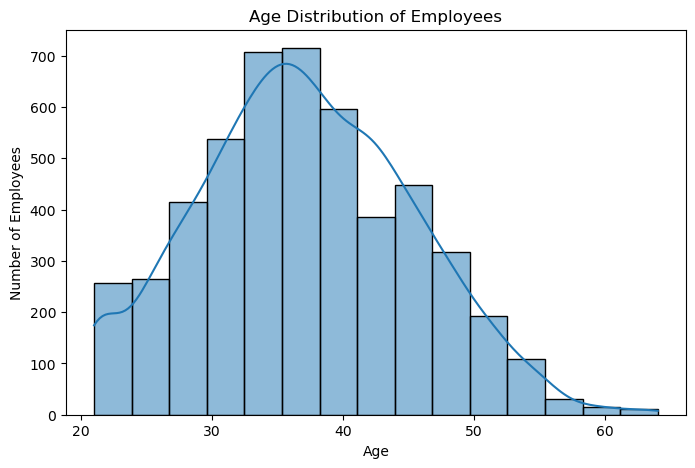

In [92]:
# Age Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='age',
    bins=15,
    kde=True
)

plt.title('Age Distribution of Employees')
plt.xlabel('Age')
plt.ylabel('Number of Employees')

plt.show()

### Salary Distribution

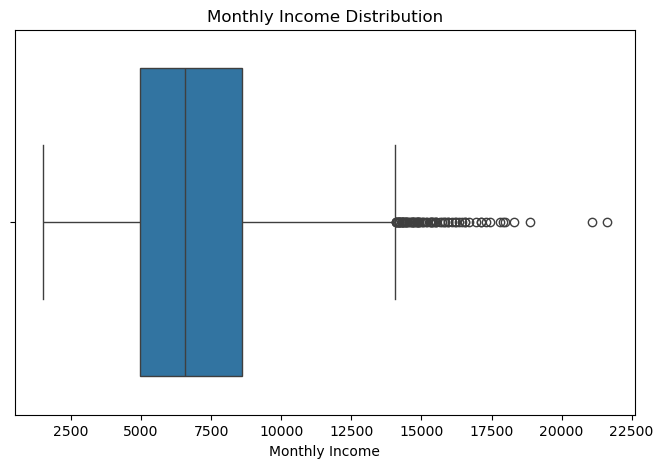

In [93]:
# Salary Distribution

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='monthly_income'
)

plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income')

plt.show()

### Department Distribution

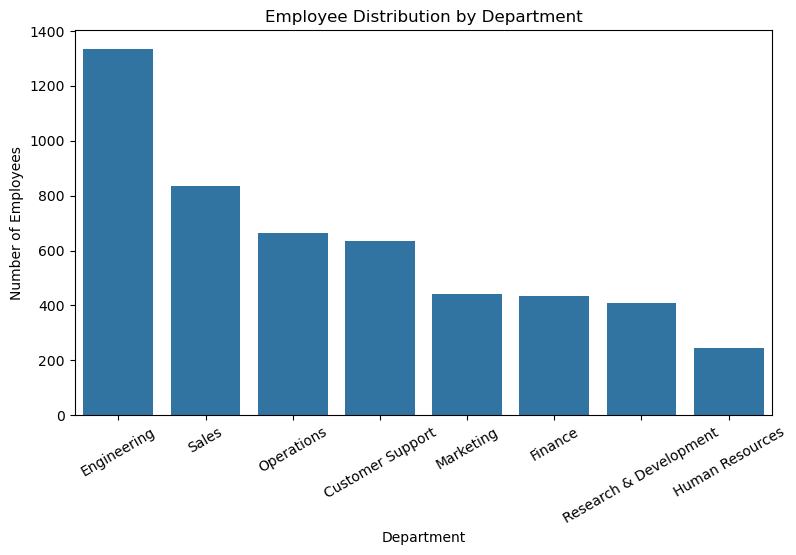

In [94]:
# Department Distribution

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='department',
    order=df['department'].value_counts().index
)

plt.title('Employee Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')

plt.xticks(rotation=30)

plt.show()

### Employee attrition distribution

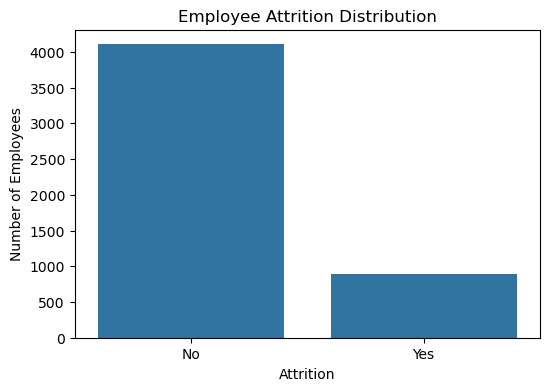

In [95]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='attrition')

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

plt.show()

### Age Group vs Attrition Rate

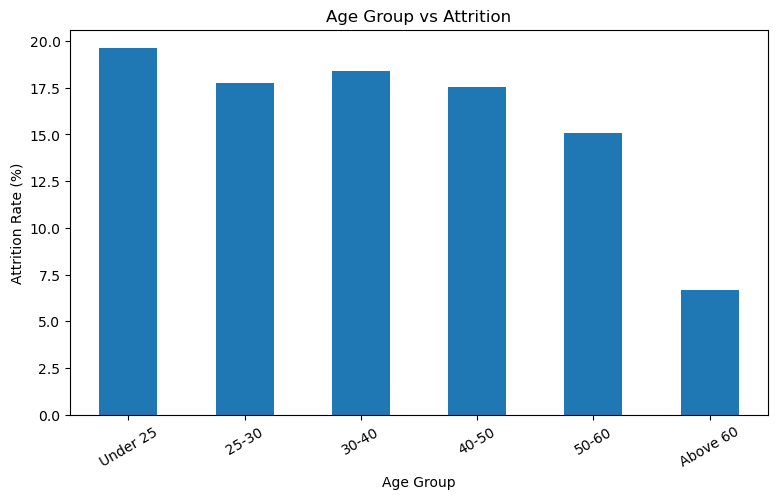

In [96]:
# Age Group vs Attrition Rate

age_attrition_rate = (
    df.groupby('age_group', observed=True)['attrition_flag']
      .mean() * 100
)

age_attrition_rate.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Age Group vs Attrition')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=30)

plt.show()

### Salary Category vs Attrition Rate

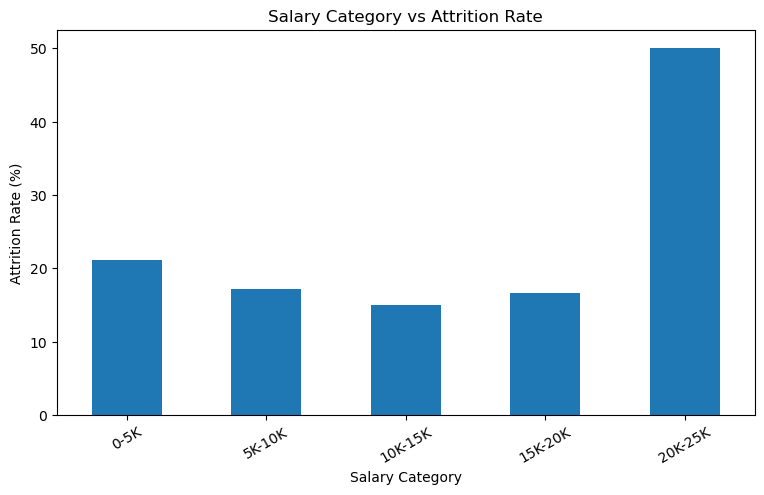

In [97]:
# Salary Category vs Attrition Rate

salary_attrition_rate = (
    df.groupby('salary_category', observed=True)['attrition_flag']
      .mean() * 100
)

salary_attrition_rate.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Salary Category vs Attrition Rate')
plt.xlabel('Salary Category')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=30)

plt.show()

### Overtime vs Attrition Rate

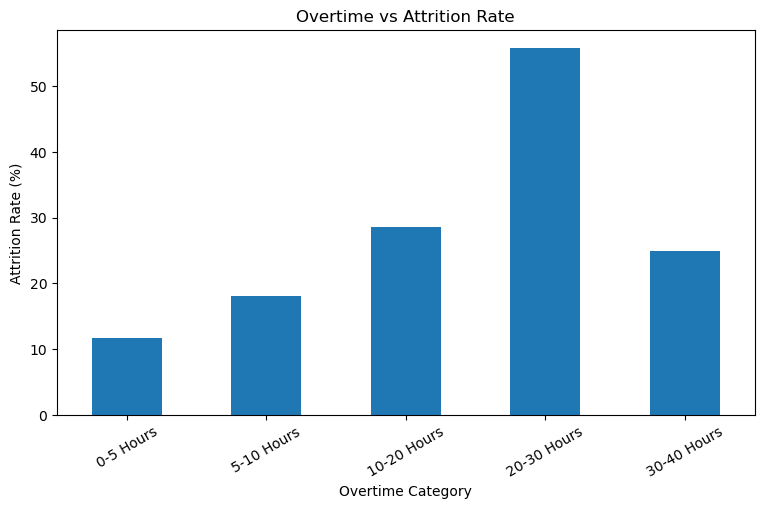

In [100]:
# Overtime vs Attrition Rate

overtime_attrition_rate = (
    df.groupby('overtime_category', observed=True)['attrition_flag']
      .mean() * 100
)

overtime_attrition_rate.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Overtime vs Attrition Rate')
plt.xlabel('Overtime Category')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=30)

plt.show()

### Burnout Category vs Attrition Rate

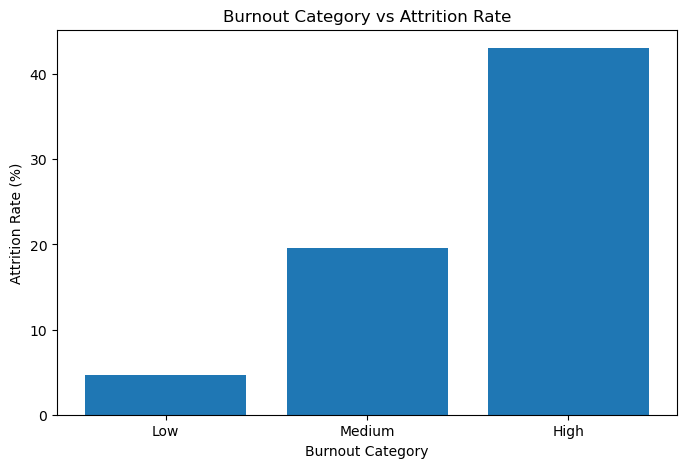

In [101]:
# Burnout Category vs Attrition Rate

burnout_attrition_rate = (
    df.groupby('burnout_category', observed=True)['attrition_flag']
      .mean() * 100
)

burnout_order = ['Low', 'Medium', 'High']

burnout_attrition_rate = burnout_attrition_rate.reindex(burnout_order)

plt.figure(figsize=(8, 5))

plt.bar(
    burnout_attrition_rate.index,
    burnout_attrition_rate.values
)

plt.title('Burnout Category vs Attrition Rate')
plt.xlabel('Burnout Category')
plt.ylabel('Attrition Rate (%)')

plt.show()

### Encagement score vs attrition

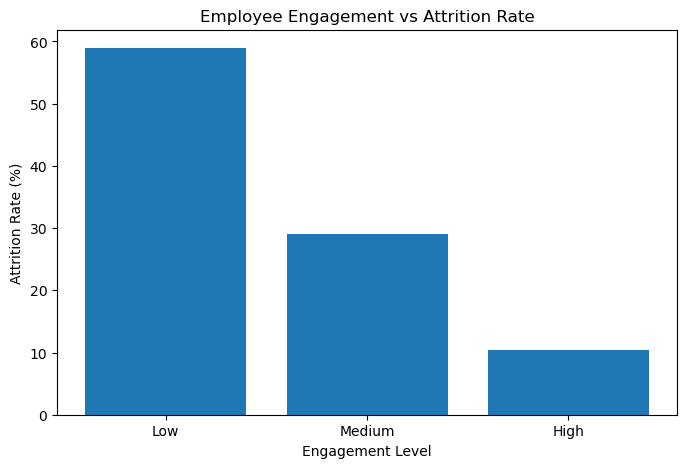

In [102]:
engagement_attrition_rate = (
    df.groupby('engagement_category', observed=True)['attrition_flag']
      .mean() * 100
)

engagement_order = ['Low', 'Medium', 'High']

engagement_attrition_rate = engagement_attrition_rate.reindex(
    engagement_order
)

plt.figure(figsize=(8, 5))

plt.bar(
    engagement_attrition_rate.index,
    engagement_attrition_rate.values
)

plt.title('Employee Engagement vs Attrition Rate')
plt.xlabel('Engagement Level')
plt.ylabel('Attrition Rate (%)')

plt.show()

### Manager support score vs attrition

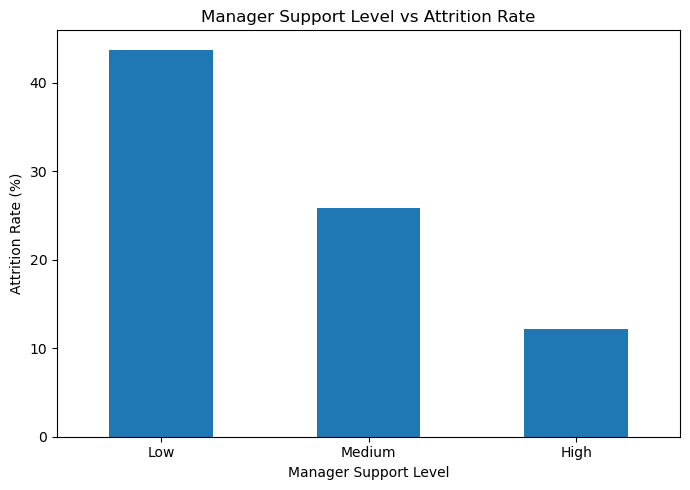

In [86]:
plt.figure(figsize=(7,5))

attrition_by_support.plot(kind='bar')

plt.title('Manager Support Level vs Attrition Rate')
plt.xlabel('Manager Support Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Worklife balance vs attrition

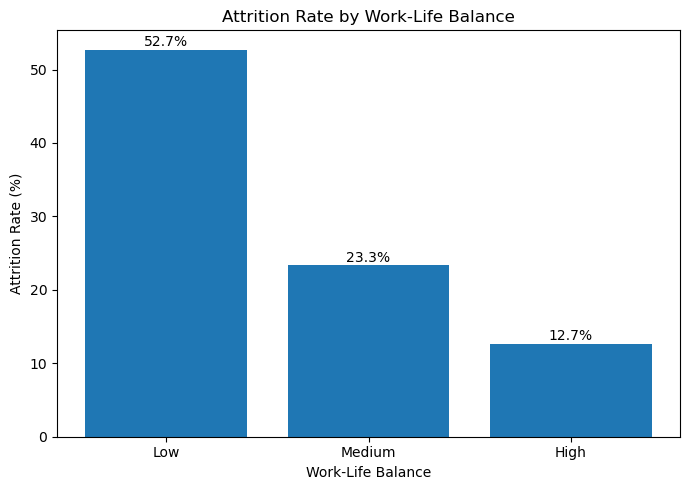

In [108]:
worklife_attrition = (
    df.groupby("worklife_balance_category", observed=True)["attrition_flag"]
    .mean() * 100
)

plt.figure(figsize=(7,5))

plt.bar(
    worklife_attrition.index,
    worklife_attrition.values
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Attrition Rate (%)")

for i, value in enumerate(worklife_attrition.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

### AI Job Risk vs Attrition Rate

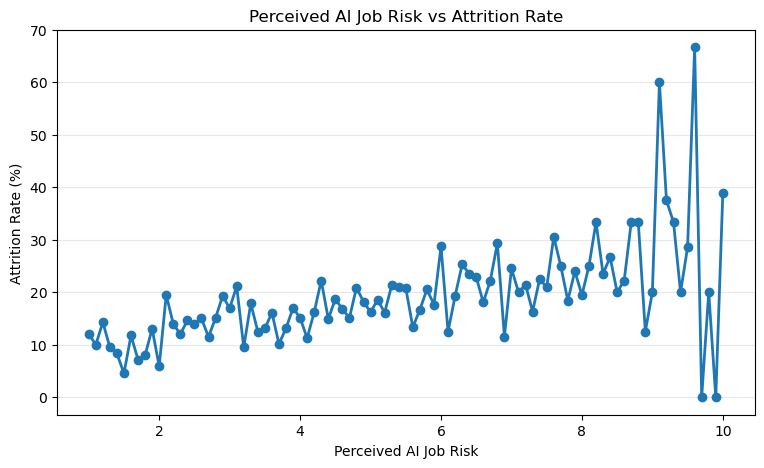

In [103]:
# AI Job Risk vs Attrition Rate

ai_risk_attrition_rate = (
    df.groupby('perceived_ai_job_risk')['attrition_flag']
      .mean() * 100
)

plt.figure(figsize=(9, 5))

plt.plot(
    ai_risk_attrition_rate.index,
    ai_risk_attrition_rate.values,
    marker='o',
    linewidth=2
)

plt.title('Perceived AI Job Risk vs Attrition Rate')
plt.xlabel('Perceived AI Job Risk')
plt.ylabel('Attrition Rate (%)')

plt.grid(axis='y', alpha=0.3)

plt.show()

In [104]:
multi_columns = [
    'engagement_score',
    'burnout_score',
    'perceived_ai_job_risk',
    'overtime_hours_per_week',
    'work_life_balance_score',
    'attrition_flag'
]

correlation_matrix = df[multi_columns].corr()

correlation_matrix

,engagement_score,burnout_score,perceived_ai_job_risk,overtime_hours_per_week,work_life_balance_score,attrition_flag
engagement_score,1.000000,-0.547906,-0.071679,-0.208832,0.265626,-0.302551
burnout_score,-0.547906,1.000000,0.141733,0.560697,-0.586325,0.311235
perceived_ai_job_risk,-0.071679,0.141733,1.000000,0.026034,-0.066506,0.095939
overtime_hours_per_week,-0.208832,0.560697,0.026034,1.000000,-0.627033,0.203050
work_life_balance_score,0.265626,-0.586325,-0.066506,-0.627033,1.000000,-0.201561
attrition_flag,-0.302551,0.311235,0.095939,0.203050,-0.201561,1.000000


MULTI VARIATE ANALYSIS HEAT MAP

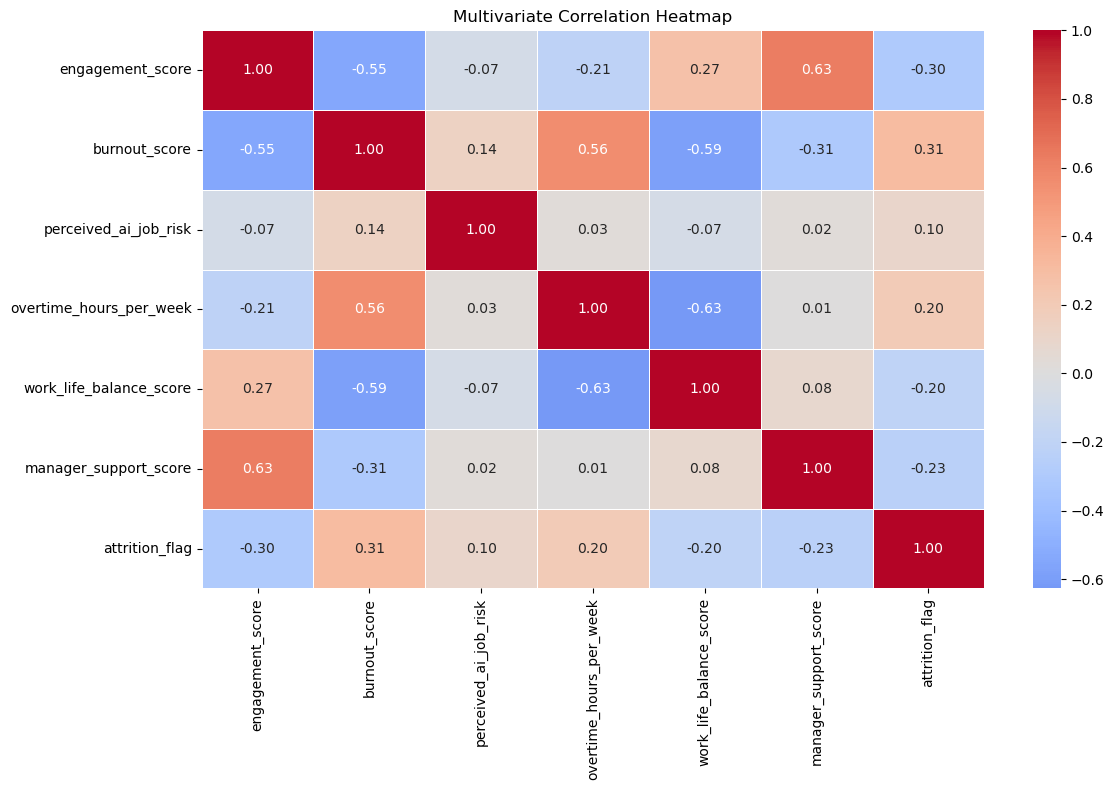

In [112]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Multivariate Correlation Heatmap")
plt.tight_layout()
plt.show()

## Final Conclusion
* Employee attrition varies across age, salary, overtime, burnout, engagement, and perceived Al job risk.

* Under-25 employees recorded the highest age-group attrition rate at approximately 19.6%.

* Attrition increases substantially with overtime, with the 20-30 hours category showing the highest rate in the analysis

* High burnout is strongly associated with higher attrition: approximately 43%, compared with about 5% for low burnout.
    
* Higher manager support level reduce the attrition rate and the lower level show higher attrition
    
* Low engagement is associated with much higher attrition, approximately 59%, while high engagement is around 10%.
    
* Higher perceived Al job risk generally shows an upward relationship with attrition, although there is considerable variation.
    
*Overall, employee well-being, engagement, workload, and job-related concerns appear to be important areas associated with employee turnover.



## Recommendations / Suggestions
1. Reduce over time by monitoring workload and staffing.
2. Address employee burnout through workload management, regular feedback, and employee-support initiatives.
3. Improve employee engagement through recognition, career-development opportunities, and employee feedback.
4. Promote work-life balance through flexible working practices and reasonable workloads.
5. Focus on younger employees, particularly the Under-25 group, through mentoring and career-development programs.
6. Monitor Al-related job concerns and provide employees with Al training and upskilling opportunities
7. Improve manager support.
8. Use department and salary-level attrition rates to identify specific groups requiring further investigation.